In [1]:
from pathlib import Path
import json
import time
import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    ParameterSampler,
    StratifiedShuffleSplit
)
from sklearn.utils.class_weight import compute_class_weight


# =========================================================
# DISPLAY SETTINGS
# =========================================================

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 100)


# =========================================================
# RANDOM STATE
# =========================================================

RANDOM_STATE = 42


# =========================================================
# TARGET CONFIGURATION
# =========================================================

TARGET = "SEVERITY"

CLASS_ORDER = [
    "CLASS - 1",
    "CLASS - 2",
    "CLASS - 3"
]


# =========================================================
# BUILDsafe PROJECT PATH
# =========================================================
#
# Your actual project is located at:
#
# C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI
#
# Inside it:
#
# BuildSafe-AI/
#     notebooks/
#         artifacts/
#
# =========================================================

PROJECT_DIR = Path(
    r"C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI"
)


# =========================================================
# ARTIFACT DIRECTORY
# =========================================================

ARTIFACT_DIR = PROJECT_DIR / "notebooks" / "artifacts"


# Check whether the project exists
if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"BuildSafe project folder was not found:\n"
        f"{PROJECT_DIR}"
    )


# Check whether artifacts exist
if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        f"BuildSafe artifacts folder was not found:\n"
        f"{ARTIFACT_DIR}"
    )


# =========================================================
# MODEL OUTPUT DIRECTORY
# =========================================================

MODEL_DIR = ARTIFACT_DIR / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# DISPLAY PATH INFORMATION
# =========================================================

print("=" * 60)
print("BuildSafe Random Forest Model Development")
print("=" * 60)

print("\nCurrent working directory:")
print(Path.cwd().resolve())

print("\nBuildSafe project directory:")
print(PROJECT_DIR.resolve())

print("\nArtifact directory:")
print(ARTIFACT_DIR.resolve())

print("\nModel output directory:")
print(MODEL_DIR.resolve())


# =========================================================
# CHECK IMPORTANT ARTIFACT FILES
# =========================================================

required_files = [
    "X_train_tree.npz",
    "X_test_tree.npz",
    "y_train.csv",
    "y_test.csv",
    "feature_names_tree.csv",
    "preprocess_tree.joblib",
    "preprocessing_config.json",
    "class_weights.json",
    "train_engineered.csv",
    "test_engineered.csv",
    "bin_history_lookup.csv",
]


print("\nChecking required artifacts...")

missing_files = []

for filename in required_files:

    file_path = ARTIFACT_DIR / filename

    if file_path.exists():
        print(f"✅ {filename}")

    else:
        print(f"❌ {filename}")
        missing_files.append(filename)


# Stop if anything important is missing
if missing_files:

    raise FileNotFoundError(
        "\nThe following required artifact files are missing:\n"
        + "\n".join(
            f"- {filename}"
            for filename in missing_files
        )
    )


print("\n" + "=" * 60)
print("✅ All required BuildSafe artifacts found.")
print("=" * 60)

BuildSafe Random Forest Model Development

Current working directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks

BuildSafe project directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI

Artifact directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts

Model output directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts\models

Checking required artifacts...
✅ X_train_tree.npz
✅ X_test_tree.npz
✅ y_train.csv
✅ y_test.csv
✅ feature_names_tree.csv
✅ preprocess_tree.joblib
✅ preprocessing_config.json
✅ class_weights.json
✅ train_engineered.csv
✅ test_engineered.csv
✅ bin_history_lookup.csv

✅ All required BuildSafe artifacts found.


In [2]:
from pathlib import Path

# Actual BuildSafe project location
PROJECT_DIR = Path(
    r"C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI"
)

ARTIFACT_DIR = PROJECT_DIR / "notebooks" / "artifacts"

# Check that the folder really exists
if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        f"Artifacts folder not found:\n{ARTIFACT_DIR}"
    )

# Folder where Random Forest model files will be saved
MODEL_DIR = ARTIFACT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nArtifact directory:")
print(ARTIFACT_DIR)

print("\nModel directory:")
print(MODEL_DIR)

Project directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI

Artifact directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts

Model directory:
C:\Users\gimha_9pk7du7\OneDrive\Desktop\projects\BuildSafe-AI\notebooks\artifacts\models


In [3]:
# 5. Load the preprocessing configuration and fitted tree pipeline

config_path = ARTIFACT_DIR / "preprocessing_config.json"
preprocess_path = ARTIFACT_DIR / "preprocess_tree.joblib"

with open(config_path, "r", encoding="utf-8") as f:
    preprocessing_config = json.load(f)

preprocess_tree_saved = joblib.load(preprocess_path)

FEATURES_FINAL = preprocessing_config["features"]
TEXT_COL = preprocessing_config["text_col"]
CAT_COLS = preprocessing_config["cat_cols"]
BIN_COLS_FINAL = preprocessing_config["bin_cols"]
NUM_COLS_FINAL = preprocessing_config["num_cols"]

K_TREE = preprocessing_config.get("k_tree", 5000)

print("Target:", TARGET)
print("Tree feature-selection k:", K_TREE)
print("Text column:", TEXT_COL)
print("Categorical columns:", CAT_COLS)
print("Binary/history columns:", BIN_COLS_FINAL)
print("Numerical columns:", NUM_COLS_FINAL)
print("\nFinal raw/engineered input columns:", FEATURES_FINAL)


Target: SEVERITY
Tree feature-selection k: 5000
Text column: DESC_CLEAN
Categorical columns: ['BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK']
Binary/history columns: ['IS_WEEKEND', 'HAS_DOB_VIOLATION']
Numerical columns: ['AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']

Final raw/engineered input columns: ['DESC_CLEAN', 'BORO', 'VIOLATION_TYPE', 'RESPONDENT_TYPE', 'DOB_UNIT', 'ISSUE_MONTH', 'ISSUE_DAYOFWEEK', 'IS_WEEKEND', 'HAS_DOB_VIOLATION', 'AGGRAVATED_ORD', 'BIN_PRIOR_VIOLATIONS', 'BIN_PRIOR_CLASS1', 'BIN_DAYS_SINCE_PREV', 'DESC_WORDS']


In [4]:
# 6. Load saved model matrices and labels

X_train_artifact = sparse.load_npz(
    ARTIFACT_DIR / "X_train_tree.npz"
)

X_test_artifact = sparse.load_npz(
    ARTIFACT_DIR / "X_test_tree.npz"
)

y_train = pd.read_csv(
    ARTIFACT_DIR / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    ARTIFACT_DIR / "y_test.csv"
).squeeze("columns")

feature_names_df = pd.read_csv(
    ARTIFACT_DIR / "feature_names_tree.csv"
)

feature_names_artifact = feature_names_df.iloc[:, 0].astype(str).to_numpy()

print("X_train:", X_train_artifact.shape)
print("X_test :", X_test_artifact.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Feature names:", len(feature_names_artifact))


X_train: (81780, 5000)
X_test : (20554, 5000)
y_train: (81780,)
y_test : (20554,)
Feature names: 5000


In [5]:
# 7. Load the human-readable engineered tables

train_engineered = pd.read_csv(
    ARTIFACT_DIR / "train_engineered.csv"
)

test_engineered = pd.read_csv(
    ARTIFACT_DIR / "test_engineered.csv"
)

train_engineered["ISSUE_DATE"] = pd.to_datetime(
    train_engineered["ISSUE_DATE"],
    errors="raise"
)

test_engineered["ISSUE_DATE"] = pd.to_datetime(
    test_engineered["ISSUE_DATE"],
    errors="raise"
)

print("train_engineered:", train_engineered.shape)
print("test_engineered :", test_engineered.shape)

print("\nTraining date range:")
print(train_engineered["ISSUE_DATE"].min(), "→", train_engineered["ISSUE_DATE"].max())

print("\nTest date range:")
print(test_engineered["ISSUE_DATE"].min(), "→", test_engineered["ISSUE_DATE"].max())


train_engineered: (81780, 17)
test_engineered : (20554, 17)

Training date range:
2025-01-01 00:00:00 → 2026-05-12 00:00:00

Test date range:
2026-05-13 00:00:00 → 2026-09-10 00:00:00


In [6]:
# 8. Alignment and leakage-safety checks

assert X_train_artifact.shape[0] == len(y_train), "X_train and y_train row counts differ."
assert X_test_artifact.shape[0] == len(y_test), "X_test and y_test row counts differ."
assert X_train_artifact.shape[1] == len(feature_names_artifact), "Feature-name count does not match X_train width."

assert set(y_train.unique()).issubset(set(CLASS_ORDER)), "Unexpected class in y_train."
assert set(y_test.unique()).issubset(set(CLASS_ORDER)), "Unexpected class in y_test."

# The preprocessing notebook saved train_engineered in the same row order
# used to create y_train.
engineered_train_labels = train_engineered[TARGET].astype(str).reset_index(drop=True)
artifact_train_labels = y_train.astype(str).reset_index(drop=True)

assert engineered_train_labels.equals(
    artifact_train_labels
), "train_engineered row order does not match y_train."

assert train_engineered["ISSUE_DATE"].max() < test_engineered["ISSUE_DATE"].min(), \
    "Training period must finish before test period."

assert TARGET not in FEATURES_FINAL, "Target leaked into FEATURES_FINAL."

print("All pre-flight checks PASSED.")


All pre-flight checks PASSED.


In [7]:
# 9. Target distribution and saved class weights

train_counts = y_train.value_counts().reindex(CLASS_ORDER)
train_pct = (train_counts / len(y_train) * 100).round(2)

target_distribution = pd.DataFrame({
    "count": train_counts,
    "percent": train_pct
})

print(target_distribution)

imbalance_ratio = train_counts.max() / train_counts.min()
print(f"\nTraining majority/minority ratio: {imbalance_ratio:.2f}:1")

with open(ARTIFACT_DIR / "class_weights.json", "r", encoding="utf-8") as f:
    saved_class_weights = json.load(f)

print("\nSaved class weights:")
print(saved_class_weights)

computed_full_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_ORDER),
    y=y_train
)

computed_full_weights = dict(
    zip(CLASS_ORDER, computed_full_weights)
)

print("\nRecomputed full-training weights:")
print({k: round(v, 3) for k, v in computed_full_weights.items()})


           count  percent
SEVERITY                 
CLASS - 1  32140    39.30
CLASS - 2  46270    56.58
CLASS - 3   3370     4.12

Training majority/minority ratio: 13.73:1

Saved class weights:
{'CLASS - 1': 0.848, 'CLASS - 2': 0.589, 'CLASS - 3': 8.089}

Recomputed full-training weights:
{'CLASS - 1': np.float64(0.848), 'CLASS - 2': np.float64(0.589), 'CLASS - 3': np.float64(8.089)}


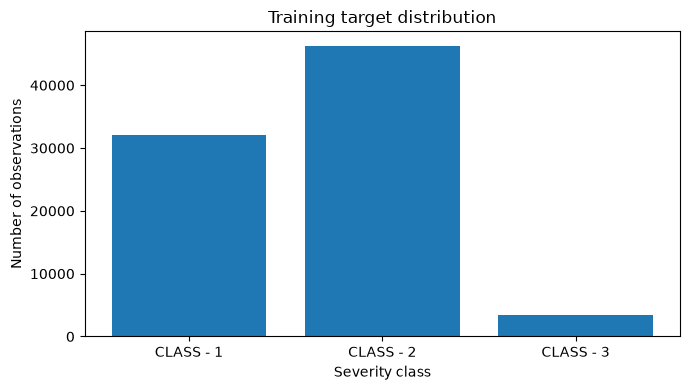

In [8]:
# 10. Visualise the training class distribution

plt.figure(figsize=(7, 4))
plt.bar(train_counts.index, train_counts.values)
plt.title("Training target distribution")
plt.xlabel("Severity class")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()


In [9]:
# 11. Build the time-ordered validation split inside TRAIN

train_engineered = train_engineered.sort_values(
    "ISSUE_DATE",
    kind="mergesort"
).reset_index(drop=True)

validation_start_idx = int(len(train_engineered) * 0.80)

dev_train = train_engineered.iloc[:validation_start_idx].copy()
validation = train_engineered.iloc[validation_start_idx:].copy()

y_dev = dev_train[TARGET].astype(str)
y_val = validation[TARGET].astype(str)

print("Development-train:")
print(f"  Rows: {len(dev_train):,}")
print(f"  Dates: {dev_train['ISSUE_DATE'].min().date()} → {dev_train['ISSUE_DATE'].max().date()}")

print("\nValidation:")
print(f"  Rows: {len(validation):,}")
print(f"  Dates: {validation['ISSUE_DATE'].min().date()} → {validation['ISSUE_DATE'].max().date()}")

dev_dist = pd.DataFrame({
    "dev_train_%": y_dev.value_counts(normalize=True).reindex(CLASS_ORDER) * 100,
    "validation_%": y_val.value_counts(normalize=True).reindex(CLASS_ORDER) * 100,
}).round(2)

print("\nClass distribution:")
display(dev_dist)


Development-train:
  Rows: 65,424
  Dates: 2025-01-01 → 2026-02-18

Validation:
  Rows: 16,356
  Dates: 2026-02-18 → 2026-05-12

Class distribution:


,dev_train_%,validation_%
SEVERITY,,
CLASS - 1,39.84,37.15
CLASS - 2,55.83,59.58
CLASS - 3,4.33,3.27


In [10]:
# =========================================================
# CHECK MISSING VALUES IN MODEL INPUT
# =========================================================

dev_input = dev_train[FEATURES_FINAL].copy()

print("Missing values in model input:")
print(
    dev_input.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Missing values in model input:
DESC_CLEAN              6
BORO                    0
VIOLATION_TYPE          0
RESPONDENT_TYPE         0
DOB_UNIT                0
ISSUE_MONTH             0
ISSUE_DAYOFWEEK         0
IS_WEEKEND              0
HAS_DOB_VIOLATION       0
AGGRAVATED_ORD          0
BIN_PRIOR_VIOLATIONS    0
BIN_PRIOR_CLASS1        0
BIN_DAYS_SINCE_PREV     0
DESC_WORDS              0
dtype: int64


In [11]:
print(
    "Missing DESC_CLEAN:",
    dev_input["DESC_CLEAN"].isna().sum()
)

Missing DESC_CLEAN: 6


In [12]:
# Create the validation input dataframe

val_input = validation[FEATURES_FINAL].copy()

print("Validation input shape:", val_input.shape)

Validation input shape: (16356, 14)


In [13]:
# =========================================================
# HANDLE MISSING TEXT VALUES
# =========================================================

# A missing violation description means there is no text
# to extract features from, so represent it as an empty string.

dev_input[TEXT_COL] = (
    dev_input[TEXT_COL]
    .fillna("")
    .astype(str)
)

val_input[TEXT_COL] = (
    val_input[TEXT_COL]
    .fillna("")
    .astype(str)
)


# ---------------------------------------------------------
# Verify
# ---------------------------------------------------------

print(
    "Missing DESC_CLEAN in development:",
    dev_input[TEXT_COL].isna().sum()
)

print(
    "Missing DESC_CLEAN in validation:",
    val_input[TEXT_COL].isna().sum()
)

Missing DESC_CLEAN in development: 0
Missing DESC_CLEAN in validation: 0


In [14]:
# =========================================================
# FIT PREPROCESSING ON DEVELOPMENT DATA
# =========================================================

# Create a fresh copy of the saved preprocessing pipeline.
# It has the same configuration, but we will fit it only
# using the development-training data.

validation_preprocess = clone(preprocess_tree_saved)


# Fit the preprocessing pipeline using DEVELOPMENT data only
X_dev = validation_preprocess.fit_transform(
    dev_input,
    y_dev
)


# Transform validation data using the already-fitted pipeline
# IMPORTANT: we do NOT call fit() on validation data.
X_val = validation_preprocess.transform(
    val_input
)


# =========================================================
# CHECK RESULTS
# =========================================================

print("Validation preprocessing completed successfully.")

print("\nX_dev shape:")
print(X_dev.shape)

print("\nX_val shape:")
print(X_val.shape)

Validation preprocessing completed successfully.

X_dev shape:
(65424, 5000)

X_val shape:
(16356, 5000)


In [15]:
# =========================================================
# VERIFY FINAL FEATURE NAMES
# =========================================================

# Get feature names before SelectKBest
base_feature_names = (
    validation_preprocess
    .named_steps["features"]
    .get_feature_names_out()
)


# Get the mask of features selected by SelectKBest
selection_mask = (
    validation_preprocess
    .named_steps["select"]
    .get_support()
)


# Apply the mask
selected_feature_names = base_feature_names[selection_mask]


# =========================================================
# CHECK
# =========================================================

print("Features before selection:")
print(len(base_feature_names))

print("\nFeatures after selection:")
print(len(selected_feature_names))

print("\nX_dev columns:")
print(X_dev.shape[1])

print("\nX_val columns:")
print(X_val.shape[1])


# Make sure everything matches
assert len(selected_feature_names) == X_dev.shape[1]
assert len(selected_feature_names) == X_val.shape[1]

print("\n✅ Feature names and matrix dimensions match.")

Features before selection:
39893

Features after selection:
5000

X_dev columns:
5000

X_val columns:
5000

✅ Feature names and matrix dimensions match.


In [16]:
# =========================================================
# RANDOM FOREST BASELINE MODEL
# =========================================================

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest Baseline")
print("=" * 50)

print("Number of trees:", rf_baseline.n_estimators)
print("Criterion:", rf_baseline.criterion)
print("Max features:", rf_baseline.max_features)
print("Bootstrap:", rf_baseline.bootstrap)
print("Class weight:", rf_baseline.class_weight)

print("\nTraining Random Forest...")

start_time = time.time()

rf_baseline.fit(
    X_dev,
    y_dev
)

training_time = time.time() - start_time

print("\n✅ Baseline Random Forest trained successfully!")
print(f"Training time: {training_time:.2f} seconds")

Random Forest Baseline
Number of trees: 100
Criterion: gini
Max features: sqrt
Bootstrap: True
Class weight: None

Training Random Forest...

✅ Baseline Random Forest trained successfully!
Training time: 15.12 seconds


In [17]:
# =========================================================
# BASELINE — VALIDATION PREDICTIONS
# =========================================================

print("Generating validation predictions...")

start_time = time.time()

y_val_pred_baseline = rf_baseline.predict(X_val)

prediction_time = time.time() - start_time

print("\n✅ Validation predictions generated.")
print("Number of predictions:", len(y_val_pred_baseline))
print(f"Prediction time: {prediction_time:.2f} seconds")

Generating validation predictions...

✅ Validation predictions generated.
Number of predictions: 16356
Prediction time: 0.10 seconds


In [18]:
# =========================================================
# BASELINE RANDOM FOREST — VALIDATION METRICS
# =========================================================

baseline_accuracy = accuracy_score(
    y_val,
    y_val_pred_baseline
)

baseline_precision = precision_score(
    y_val,
    y_val_pred_baseline,
    average="macro",
    zero_division=0
)

baseline_recall = recall_score(
    y_val,
    y_val_pred_baseline,
    average="macro",
    zero_division=0
)

baseline_f1 = f1_score(
    y_val,
    y_val_pred_baseline,
    average="macro",
    zero_division=0
)

print("Baseline Random Forest — Validation Results")
print("=" * 55)

print(f"Accuracy:         {baseline_accuracy:.4f}  ({baseline_accuracy * 100:.2f}%)")
print(f"Macro Precision:  {baseline_precision:.4f}  ({baseline_precision * 100:.2f}%)")
print(f"Macro Recall:     {baseline_recall:.4f}  ({baseline_recall * 100:.2f}%)")
print(f"Macro F1:         {baseline_f1:.4f}  ({baseline_f1 * 100:.2f}%)")

Baseline Random Forest — Validation Results
Accuracy:         0.8511  (85.11%)
Macro Precision:  0.8437  (84.37%)
Macro Recall:     0.7314  (73.14%)
Macro F1:         0.7717  (77.17%)


In [19]:
# =========================================================
# RANDOM FOREST — CLASS-WEIGHTED MODEL
# =========================================================

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest Class-Weighted Model")
print("=" * 50)

print("Number of trees:", rf_weighted.n_estimators)
print("Criterion:", rf_weighted.criterion)
print("Max features:", rf_weighted.max_features)
print("Bootstrap:", rf_weighted.bootstrap)
print("Class weight:", rf_weighted.class_weight)

print("\nTraining class-weighted Random Forest...")

start_time = time.time()

rf_weighted.fit(
    X_dev,
    y_dev
)

weighted_training_time = time.time() - start_time

print("\n✅ Class-weighted Random Forest trained successfully!")
print(f"Training time: {weighted_training_time:.2f} seconds")

Random Forest Class-Weighted Model
Number of trees: 100
Criterion: gini
Max features: sqrt
Bootstrap: True
Class weight: balanced

Training class-weighted Random Forest...

✅ Class-weighted Random Forest trained successfully!
Training time: 14.48 seconds


In [20]:
# =========================================================
# CLASS-WEIGHTED RF — VALIDATION PREDICTIONS
# =========================================================

print("Generating validation predictions...")

start_time = time.time()

y_val_pred_weighted = rf_weighted.predict(X_val)

weighted_prediction_time = time.time() - start_time

print("\n✅ Validation predictions generated.")
print("Number of predictions:", len(y_val_pred_weighted))
print(f"Prediction time: {weighted_prediction_time:.2f} seconds")

Generating validation predictions...

✅ Validation predictions generated.
Number of predictions: 16356
Prediction time: 0.10 seconds


In [21]:
# =========================================================
# CLASS-WEIGHTED RF — ACCURACY
# =========================================================

weighted_accuracy = accuracy_score(
    y_val,
    y_val_pred_weighted
)

print("Class-Weighted Random Forest Accuracy:")
print(f"{weighted_accuracy:.4f}")
print(f"{weighted_accuracy * 100:.2f}%")

Class-Weighted Random Forest Accuracy:
0.8439
84.39%


In [22]:
# =========================================================
# CLASS-WEIGHTED RF — MACRO PRECISION
# =========================================================

weighted_precision = precision_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

print("Class-Weighted Random Forest Macro Precision:")
print(f"{weighted_precision:.4f}")
print(f"{weighted_precision * 100:.2f}%")

Class-Weighted Random Forest Macro Precision:
0.7716
77.16%


In [23]:
# =========================================================
# CLASS-WEIGHTED RF — MACRO RECALL
# =========================================================

weighted_recall = recall_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

print("Class-Weighted Random Forest Macro Recall:")
print(f"{weighted_recall:.4f}")
print(f"{weighted_recall * 100:.2f}%")

Class-Weighted Random Forest Macro Recall:
0.7982
79.82%


In [24]:
# =========================================================
# CLASS-WEIGHTED RF — MACRO F1
# =========================================================

weighted_f1 = f1_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

print("Class-Weighted Random Forest Macro F1:")
print(f"{weighted_f1:.4f}")
print(f"{weighted_f1 * 100:.2f}%")

Class-Weighted Random Forest Macro F1:
0.7833
78.33%


In [25]:
# =========================================================
# CLASS-WEIGHTED RF — CLASS-BY-CLASS PERFORMANCE
# =========================================================

print(
    classification_report(
        y_val,
        y_val_pred_weighted,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

   CLASS - 1     0.7846    0.8713    0.8257      6076
   CLASS - 2     0.9022    0.8354    0.8675      9745
   CLASS - 3     0.6280    0.6879    0.6566       535

    accuracy                         0.8439     16356
   macro avg     0.7716    0.7982    0.7833     16356
weighted avg     0.8496    0.8439    0.8451     16356



In [26]:
# =========================================================
# CLASS-WEIGHTED RF — CONFUSION MATRIX
# =========================================================

cm_weighted = confusion_matrix(
    y_val,
    y_val_pred_weighted,
    labels=CLASS_ORDER
)

print("Class-Weighted Random Forest Confusion Matrix:")
print(cm_weighted)

Class-Weighted Random Forest Confusion Matrix:
[[5294  765   17]
 [1403 8141  201]
 [  50  117  368]]


In [27]:
# =========================================================
# SINGLE RECORD PREDICTION DEMONSTRATION
# =========================================================

# Select one validation record
sample_index = 0

# Get the actual severity
actual_class = y_val.iloc[sample_index]

# Get the Random Forest prediction
predicted_class = y_val_pred_baseline[sample_index]

print("Single Violation Prediction")
print("=" * 50)

print("Validation record index:", sample_index)
print("Actual Severity:       ", actual_class)
print("Predicted Severity:    ", predicted_class)

if actual_class == predicted_class:
    print("\n✅ Prediction CORRECT")
else:
    print("\n❌ Prediction INCORRECT")

Single Violation Prediction
Validation record index: 0
Actual Severity:        CLASS - 1
Predicted Severity:     CLASS - 1

✅ Prediction CORRECT


In [28]:
# =========================================================
# CHECK CURRENT ARTIFACT DATASET DATE RANGES
# =========================================================

train_artifact = pd.read_csv(
    ARTIFACT_DIR / "train_engineered.csv"
)

test_artifact = pd.read_csv(
    ARTIFACT_DIR / "test_engineered.csv"
)

print("TRAIN ENGINEERED")
print("Shape:", train_artifact.shape)

print(
    "Date range:",
    pd.to_datetime(train_artifact["ISSUE_DATE"]).min(),
    "→",
    pd.to_datetime(train_artifact["ISSUE_DATE"]).max()
)

print("\nTEST ENGINEERED")
print("Shape:", test_artifact.shape)

print(
    "Date range:",
    pd.to_datetime(test_artifact["ISSUE_DATE"]).min(),
    "→",
    pd.to_datetime(test_artifact["ISSUE_DATE"]).max()
)

TRAIN ENGINEERED
Shape: (81780, 17)
Date range: 2025-01-01 00:00:00 → 2026-05-12 00:00:00

TEST ENGINEERED
Shape: (20554, 17)
Date range: 2026-05-13 00:00:00 → 2026-09-10 00:00:00


Define the Hyperparameter Search Space

In [29]:
# =========================================================
# STAGE 7 — RANDOM FOREST HYPERPARAMETER SEARCH SPACE
# =========================================================

rf_param_distributions = {
    "n_estimators": [100, 200, 300],
    
    "max_depth": [None, 20, 30, 40],
    
    "min_samples_split": [2, 5, 10],
    
    "min_samples_leaf": [1, 2, 4],
    
    "max_features": ["sqrt", "log2"],
    
    "class_weight": [None, "balanced"]
}

print("Random Forest Hyperparameter Search Space")
print("=" * 55)

for parameter, values in rf_param_distributions.items():
    print(f"{parameter}: {values}")

Random Forest Hyperparameter Search Space
n_estimators: [100, 200, 300]
max_depth: [None, 20, 30, 40]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 4]
max_features: ['sqrt', 'log2']
class_weight: [None, 'balanced']


In [30]:
# =========================================================
# STAGE 7 — RANDOMIZED SEARCH SETUP
# =========================================================

from sklearn.model_selection import RandomizedSearchCV

rf_base_for_tuning = RandomForestClassifier(
    random_state=RANDOM_STATE,
    bootstrap=True
)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base_for_tuning,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Randomized Search configured successfully.")
print("Number of parameter combinations to test:", 20)
print("Scoring metric:", "Macro F1")
print("Cross-validation folds:", 3)

Randomized Search configured successfully.
Number of parameter combinations to test: 20
Scoring metric: Macro F1
Cross-validation folds: 3


In [31]:
# =========================================================
# STAGE 7 — RUN RANDOMIZED SEARCH
# =========================================================

print("Starting Random Forest hyperparameter tuning...")
print("This may take some time because multiple models will be trained.\n")

tuning_start = time.time()

rf_random_search.fit(
    X_dev,
    y_dev
)

tuning_time = time.time() - tuning_start

print("\n" + "=" * 60)
print("RANDOMIZED SEARCH COMPLETED")
print("=" * 60)

print(f"Tuning time: {tuning_time / 60:.2f} minutes")
print(f"Models evaluated: {len(rf_random_search.cv_results_['params'])}")

Starting Random Forest hyperparameter tuning...
This may take some time because multiple models will be trained.

Fitting 3 folds for each of 20 candidates, totalling 60 fits

RANDOMIZED SEARCH COMPLETED
Tuning time: 4.55 minutes
Models evaluated: 20


In [32]:
# =========================================================
# STAGE 7 — BEST RANDOM FOREST HYPERPARAMETERS
# =========================================================

print("Best Random Forest Hyperparameters")
print("=" * 55)

print(rf_random_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(f"{rf_random_search.best_score_:.4f}")
print(f"{rf_random_search.best_score_ * 100:.2f}%")

Best Random Forest Hyperparameters
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None}

Best Cross-Validation Macro F1:
0.7184
71.84%


In [33]:
# =========================================================
# STAGE 7 — EVALUATE TUNED RANDOM FOREST
# =========================================================

print("Generating predictions using the tuned Random Forest...")

tuned_start = time.time()

# Best model found by RandomizedSearchCV
best_rf = rf_random_search.best_estimator_

# Predict on the untouched validation set
y_val_pred_tuned = best_rf.predict(X_val)

tuned_prediction_time = time.time() - tuned_start

print("\n✅ Tuned validation predictions generated.")
print(f"Number of predictions: {len(y_val_pred_tuned)}")
print(f"Prediction time: {tuned_prediction_time:.2f} seconds")

Generating predictions using the tuned Random Forest...

✅ Tuned validation predictions generated.
Number of predictions: 16356
Prediction time: 1.12 seconds


In [34]:
# =========================================================
# STAGE 7 — TUNED RANDOM FOREST VALIDATION METRICS
# =========================================================

tuned_accuracy = accuracy_score(
    y_val,
    y_val_pred_tuned
)

tuned_precision = precision_score(
    y_val,
    y_val_pred_tuned,
    average="macro",
    zero_division=0
)

tuned_recall = recall_score(
    y_val,
    y_val_pred_tuned,
    average="macro",
    zero_division=0
)

tuned_f1 = f1_score(
    y_val,
    y_val_pred_tuned,
    average="macro",
    zero_division=0
)

print("Tuned Random Forest — Validation Results")
print("=" * 55)

print(f"Accuracy:         {tuned_accuracy:.4f}  ({tuned_accuracy * 100:.2f}%)")
print(f"Macro Precision:  {tuned_precision:.4f}  ({tuned_precision * 100:.2f}%)")
print(f"Macro Recall:     {tuned_recall:.4f}  ({tuned_recall * 100:.2f}%)")
print(f"Macro F1:         {tuned_f1:.4f}  ({tuned_f1 * 100:.2f}%)")

Tuned Random Forest — Validation Results
Accuracy:         0.8472  (84.72%)
Macro Precision:  0.8462  (84.62%)
Macro Recall:     0.7154  (71.54%)
Macro F1:         0.7593  (75.93%)


In [35]:
# =========================================================
# STAGE 7 — TUNED RANDOM FOREST CLASSIFICATION REPORT
# =========================================================

print("Tuned Random Forest — Classification Report")
print("=" * 65)

tuned_classification_report = classification_report(
    y_val,
    y_val_pred_tuned,
    labels=CLASS_ORDER,
    target_names=CLASS_ORDER,
    digits=4,
    zero_division=0
)

print(tuned_classification_report)

Tuned Random Forest — Classification Report
              precision    recall  f1-score   support

   CLASS - 1     0.8268    0.8074    0.8170      6076
   CLASS - 2     0.8589    0.8940    0.8761      9745
   CLASS - 3     0.8530    0.4449    0.5848       535

    accuracy                         0.8472     16356
   macro avg     0.8462    0.7154    0.7593     16356
weighted avg     0.8468    0.8472    0.8446     16356



In [36]:
# =========================================================
# STAGE 7 — TUNED RANDOM FOREST CONFUSION MATRIX
# =========================================================

cm_tuned = confusion_matrix(
    y_val,
    y_val_pred_tuned,
    labels=CLASS_ORDER
)

print("Tuned Random Forest Confusion Matrix:")
print(cm_tuned)

Tuned Random Forest Confusion Matrix:
[[4906 1170    0]
 [ 992 8712   41]
 [  36  261  238]]


In [37]:
# =========================================================
# STAGE 7 — COLLECT STAGE 6 RF RESULTS
# =========================================================

print("Stage 6 Random Forest Results")
print("=" * 60)

print(f"Baseline RF:")
print(f"  Accuracy:        {baseline_accuracy:.4f} ({baseline_accuracy * 100:.2f}%)")
print(f"  Macro Precision: {baseline_precision:.4f} ({baseline_precision * 100:.2f}%)")
print(f"  Macro Recall:    {baseline_recall:.4f} ({baseline_recall * 100:.2f}%)")
print(f"  Macro F1:        {baseline_f1:.4f} ({baseline_f1 * 100:.2f}%)")

print("\nClass-Weighted RF:")
print(f"  Accuracy:        {weighted_accuracy:.4f} ({weighted_accuracy * 100:.2f}%)")
print(f"  Macro Precision: {weighted_precision:.4f} ({weighted_precision * 100:.2f}%)")
print(f"  Macro Recall:    {weighted_recall:.4f} ({weighted_recall * 100:.2f}%)")
print(f"  Macro F1:        {weighted_f1:.4f} ({weighted_f1 * 100:.2f}%)")

Stage 6 Random Forest Results
Baseline RF:
  Accuracy:        0.8511 (85.11%)
  Macro Precision: 0.8437 (84.37%)
  Macro Recall:    0.7314 (73.14%)
  Macro F1:        0.7717 (77.17%)

Class-Weighted RF:
  Accuracy:        0.8439 (84.39%)
  Macro Precision: 0.7716 (77.16%)
  Macro Recall:    0.7982 (79.82%)
  Macro F1:        0.7833 (78.33%)


In [38]:
# =========================================================
# STAGE 7 — TUNED + CLASS-WEIGHTED RANDOM FOREST
# =========================================================

tuned_balanced_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    class_weight="balanced",
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training Tuned + Class-Weighted Random Forest...")

tuned_balanced_start = time.time()

tuned_balanced_rf.fit(
    X_dev,
    y_dev
)

tuned_balanced_training_time = time.time() - tuned_balanced_start

print("\n✅ Tuned + Class-Weighted Random Forest trained successfully!")
print(
    f"Training time: "
    f"{tuned_balanced_training_time:.2f} seconds"
)

Training Tuned + Class-Weighted Random Forest...

✅ Tuned + Class-Weighted Random Forest trained successfully!
Training time: 6.49 seconds


In [39]:
# =========================================================
# STAGE 7 — TUNED + CLASS-WEIGHTED RF PREDICTIONS
# =========================================================

print("Generating predictions using Tuned + Class-Weighted RF...")

tuned_balanced_start = time.time()

y_val_pred_tuned_balanced = tuned_balanced_rf.predict(X_val)

tuned_balanced_prediction_time = time.time() - tuned_balanced_start

print("\n✅ Tuned + Class-Weighted validation predictions generated.")
print(f"Number of predictions: {len(y_val_pred_tuned_balanced)}")
print(
    f"Prediction time: "
    f"{tuned_balanced_prediction_time:.2f} seconds"
)

Generating predictions using Tuned + Class-Weighted RF...

✅ Tuned + Class-Weighted validation predictions generated.
Number of predictions: 16356
Prediction time: 0.14 seconds


In [40]:
# =========================================================
# STAGE 7 — TUNED + CLASS-WEIGHTED RF METRICS
# =========================================================

tuned_balanced_accuracy = accuracy_score(
    y_val,
    y_val_pred_tuned_balanced
)

tuned_balanced_precision = precision_score(
    y_val,
    y_val_pred_tuned_balanced,
    average="macro",
    zero_division=0
)

tuned_balanced_recall = recall_score(
    y_val,
    y_val_pred_tuned_balanced,
    average="macro",
    zero_division=0
)

tuned_balanced_f1 = f1_score(
    y_val,
    y_val_pred_tuned_balanced,
    average="macro",
    zero_division=0
)

print("Tuned + Class-Weighted Random Forest — Validation Results")
print("=" * 65)

print(
    f"Accuracy:         {tuned_balanced_accuracy:.4f} "
    f"({tuned_balanced_accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision:  {tuned_balanced_precision:.4f} "
    f"({tuned_balanced_precision * 100:.2f}%)"
)

print(
    f"Macro Recall:     {tuned_balanced_recall:.4f} "
    f"({tuned_balanced_recall * 100:.2f}%)"
)

print(
    f"Macro F1:         {tuned_balanced_f1:.4f} "
    f"({tuned_balanced_f1 * 100:.2f}%)"
)

Tuned + Class-Weighted Random Forest — Validation Results
Accuracy:         0.8355 (83.55%)
Macro Precision:  0.7494 (74.94%)
Macro Recall:     0.8131 (81.31%)
Macro F1:         0.7757 (77.57%)


In [41]:
# =========================================================
# STAGE 7 — CLASS 3 PERFORMANCE COMPARISON
# =========================================================

from sklearn.metrics import precision_recall_fscore_support

# ---------------------------------------------------------
# Store predictions from all four experiments
# ---------------------------------------------------------

experiment_predictions = {
    "Baseline RF": y_val_pred_baseline,
    "Class-Weighted RF": y_val_pred_weighted,
    "Tuned RF": y_val_pred_tuned,
    "Tuned + Class-Weighted RF": y_val_pred_tuned_balanced
}

# ---------------------------------------------------------
# Calculate Class 3 metrics
# ---------------------------------------------------------

class3_results = []

for experiment_name, predictions in experiment_predictions.items():

    precision, recall, f1, support = precision_recall_fscore_support(
        y_val,
        predictions,
        labels=["CLASS - 3"],
        average=None,
        zero_division=0
    )

    class3_results.append({
        "Experiment": experiment_name,
        "Class 3 Precision": precision[0],
        "Class 3 Recall": recall[0],
        "Class 3 F1": f1[0],
        "Class 3 Support": support[0]
    })

class3_comparison = pd.DataFrame(class3_results)

# ---------------------------------------------------------
# Display percentages
# ---------------------------------------------------------

for column in [
    "Class 3 Precision",
    "Class 3 Recall",
    "Class 3 F1"
]:
    class3_comparison[column] = (
        class3_comparison[column] * 100
    )

print("CLASS 3 PERFORMANCE COMPARISON")
print("=" * 80)

display(
    class3_comparison.style.format({
        "Class 3 Precision": "{:.2f}%",
        "Class 3 Recall": "{:.2f}%",
        "Class 3 F1": "{:.2f}%",
        "Class 3 Support": "{:.0f}"
    })
)

CLASS 3 PERFORMANCE COMPARISON


,Experiment,Class 3 Precision,Class 3 Recall,Class 3 F1,Class 3 Support
0,Baseline RF,83.82%,48.41%,61.37%,535
1,Class-Weighted RF,62.80%,68.79%,65.66%,535
2,Tuned RF,85.30%,44.49%,58.48%,535
3,Tuned + Class-Weighted RF,57.00%,75.33%,64.90%,535


In [42]:
import os

print(os.path.exists("../models/random_forest_class_weighted.pkl"))

True


In [44]:
import joblib

model = joblib.load("../models/random_forest_class_weighted.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [45]:
[name for name in globals() if "pred" in name.lower()]

['y_val_pred_baseline',
 'prediction_time',
 'y_val_pred_weighted',
 'weighted_prediction_time',
 'predicted_class',
 'y_val_pred_tuned',
 'tuned_prediction_time',
 'y_val_pred_tuned_balanced',
 'tuned_balanced_prediction_time',
 'experiment_predictions',
 'predictions']

In [46]:
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

# Calculate validation metrics from actual predictions
accuracy = accuracy_score(
    y_val,
    y_val_pred_weighted
)

macro_precision = precision_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_val_pred_weighted,
    average="macro",
    zero_division=0
)

# Per-class metrics
per_class = classification_report(
    y_val,
    y_val_pred_weighted,
    output_dict=True,
    zero_division=0
)

# Create results dictionary
results = {
    "member_model": "Random Forest",
    "configuration": "Class-Weighted",
    
    "features": "X_train_tree.npz",
    
    "validation_results": {
        "accuracy": round(float(accuracy), 4),
        "macro_precision": round(float(macro_precision), 4),
        "macro_recall": round(float(macro_recall), 4),
        "macro_f1": round(float(macro_f1), 4)
    },
    
    "per_class_validation": per_class
}

# Save JSON
with open(RESULTS / "random_forest.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Random Forest results saved successfully.")
print(f"📁 Location: {RESULTS / 'random_forest.json'}")

✅ Random Forest results saved successfully.
📁 Location: ..\results\random_forest.json
